# Imports

In [ ]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

In [ ]:


import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
import numpy as np
from scipy.ndimage import zoom

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1

In [8]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


# Get data

In [9]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


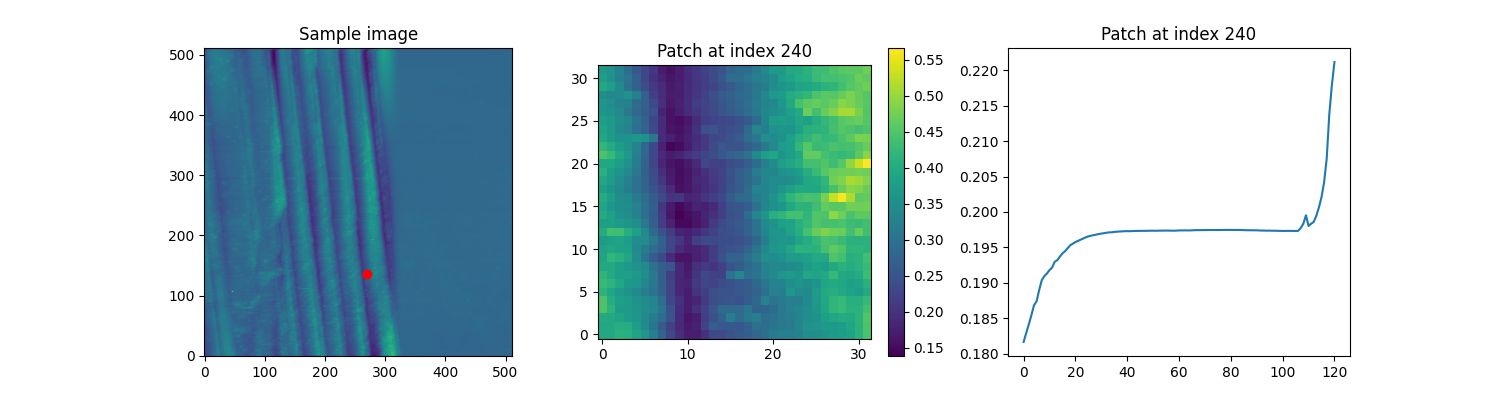

In [10]:
WS = 32
n_epochs_im2spec = 100
n_epochs_error = 100
error_type = "cos" # "L1", "L2", or "cos"

images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS, 
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 240

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [11]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]

## Augment across scales

In [12]:
images, spectra, scale_coordinates = append_multiscale_data(images, spectra, scales=np.arange(4, WS, 2), 
                                                            coordinates=swap_coordinates, 
                                                            append_image_type='pad')

Augmented images shape: (15360, 32, 32), Augmented spectra shape: (15360, 121), Augmented coordinates shape: (15360, 3)


## Train/test split

In [13]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test = train_test_split(
    images, spectra, test_size=0.7, random_state=42
)

print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (4608, 32, 32)
images_test shape: (10752, 32, 32)
spectra_train shape: (4608, 121)
spectra_test shape: (10752, 121)


## Model dimensions

In [14]:

print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (15360, 32, 32)
spectra shape: (15360, 121)


# Train im2spec

## IM2SPEC model

In [15]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FNO_im2spec mode. Trains better with interpolation based augmentation.
# imspec_model = FNO_im2spec(
#     target_size=out_dim,
#     latent_dim=3,
#     hidden_channels=32,
#     n_modes=(16, 16),
#     n_layers=4,
# ).to(device)

# Use this normal im2spec. Augmentation by padding works better here.
imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)


/home/cloud/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


100%|██████████| 100/100 [00:47<00:00,  2.10it/s, train_loss=0.0013, val_loss=0.0015]


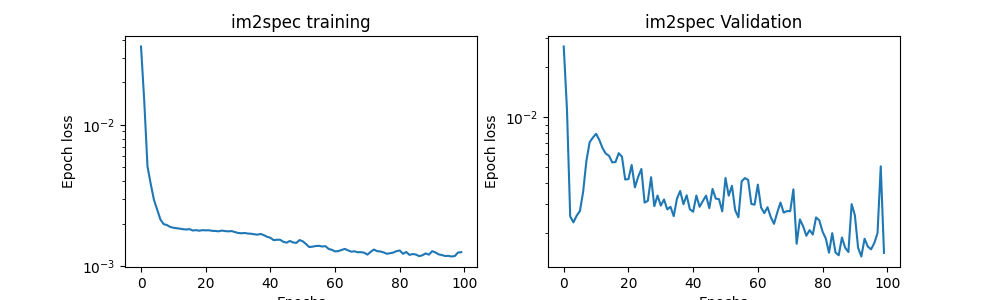

im2spec final train loss: 0.001253632615165164
im2spec final internal val loss: 0.0015148449650344749
im2spec held-out test loss: 0.0015148456441238523


In [16]:


im2spec_training_dataset = TensorDataset(
    torch.tensor(images_train, dtype=torch.float32),
    torch.tensor(spectra_train, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test, dtype=torch.float32),
    torch.tensor(spectra_test, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


# Estimate error

In [17]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_train, spectra_train, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)

print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)

# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)


error_mean shape: (4608,)
error_vector shape: (4608, 1)
error_targets shape: (4608, 1)


## Train error model

100%|██████████| 100/100 [00:19<00:00,  5.14it/s, train_loss=0.0002, val_loss=0.0002]


error model final train loss: 0.00015262928757562934
error model final val loss: 0.00019017249724129215


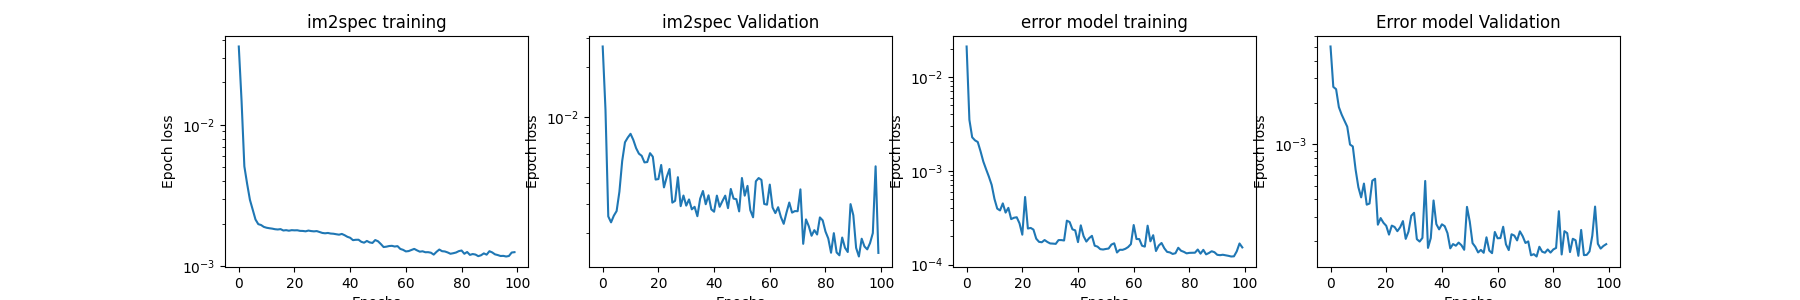

In [18]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_train, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

# Predict all errors

In [19]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (15360,)
predicted_errors range: -0.0158097967505455 0.028686288744211197


## Acquisition function

In [20]:
from nnerror.training_functions import distance_acq_fn
from nnerror.plot_functions import plot_error_prediction, plot_spectra


#beta=0 is explotation. aq_fn is inverse to errors
aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
print(aq_fn.shape)


(15360,)


# Visualize acquisition results

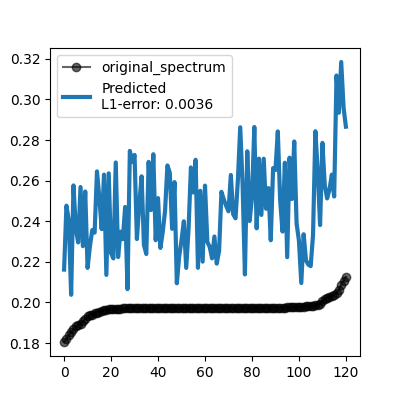

In [21]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = scale_coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1], error_type=error_type)
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean())

## 3D error and acquisition view

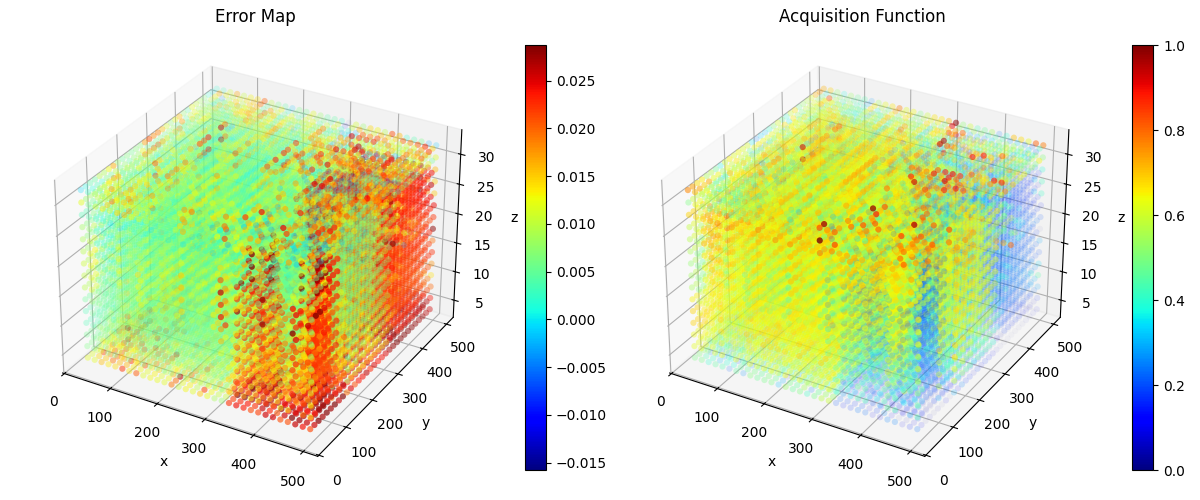

In [22]:
plot_error_prediction_3d(predicted_errors, aq_fn, scale_coordinates, aq_ind, alpha_scale=True, 
                         colormap="jet", )

## Scale-specific error maps

In [23]:
plot_scale_slider(scale_coordinates, predicted_errors, aq_fn, colormap="jet")

interactive(children=(SelectionSlider(description='Scale', options=(4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.…